## MULTIPLE LINEAR REGRESSION — Toyota Corolla Price Prediction

### Objective
Predict the offer price (in EUROs) of a used Toyota Corolla from its attributes (age, mileage, engine specs, fuel type, etc.) using Multiple Linear Regression, and compare a plain OLS approach against regularized (Ridge, Lasso) variants.

### Dataset
1,436 used Toyota Corolla listings with 10 columns: `Price`, `Age_08_04` (age in months as of Aug 2004), `KM`, `Fuel_Type` (Petrol/Diesel/CNG), `HP`, `Automatic` (1/0), `cc`, `Doors`, `Cylinders`, `Gears`, `Weight`.

### 1. Exploratory Data Analysis & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('ToyotaCorolla_-_MLR.csv')
df.head()

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  \
0  13500         23  46986    Diesel  90          0  2000      3   
1  13750         23  72937    Diesel  90          0  2000      3   
2  13950         24  41711    Diesel  90          0  2000      3   
3  14950         26  48000    Diesel  90          0  2000      3   
4  13750         30  38500    Diesel  90          0  2000      3   

   Cylinders  Gears  Weight  
0          4      5    1165  
1          4      5    1165  
2          4      5    1165  
3          4      5    1165  
4          4      5    1170  

In [2]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

Missing values per column:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Duplicate rows: 0


**No missing values or duplicate rows.** However, `df.describe()` reveals that `Cylinders` has **zero variance** (every car has 4 cylinders), so it carries no predictive information and will be dropped.

In [3]:
df.describe()

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears       Weight  
count  1436.000000  1436.000000     1436.0  1436.000000  1436.000000  
mean   1566.827994     4.033426        4.0     5.026462  1072.459610  
std     187.182436     0.952677        0.0     0.188510    52.641120  
min    1300.000000     2.000000        4.0     3.000000  1000.000000  
max    32500.000000     6.000000        4.0     6.000000  1615.000000  

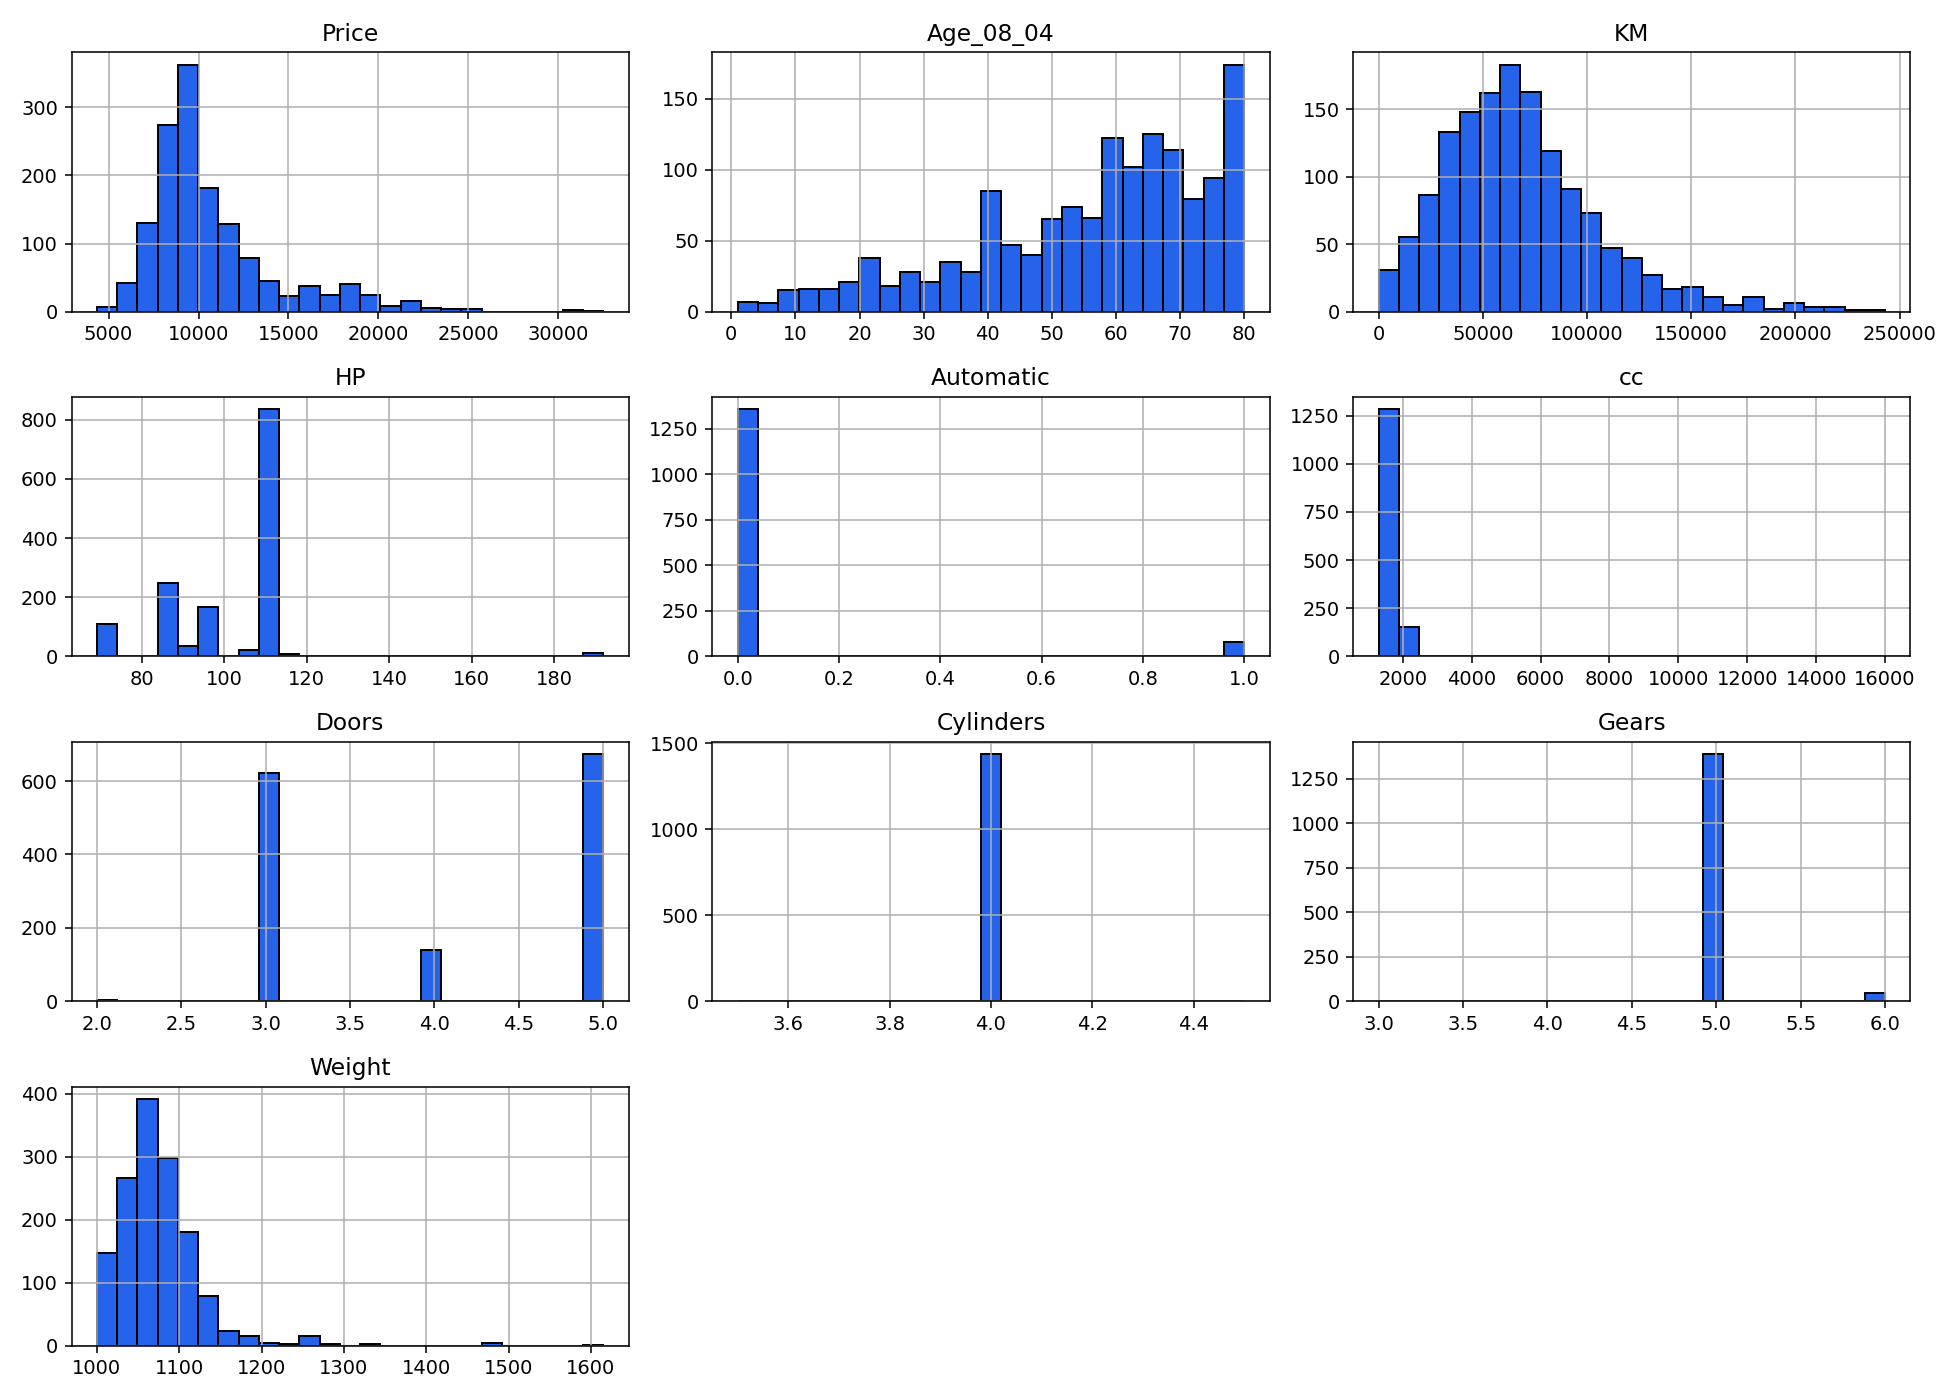

In [4]:
# Distributions of the numeric variables
df.hist(figsize=(14, 10), bins=25, color='#2563eb', edgecolor='black')
plt.tight_layout()
plt.show()

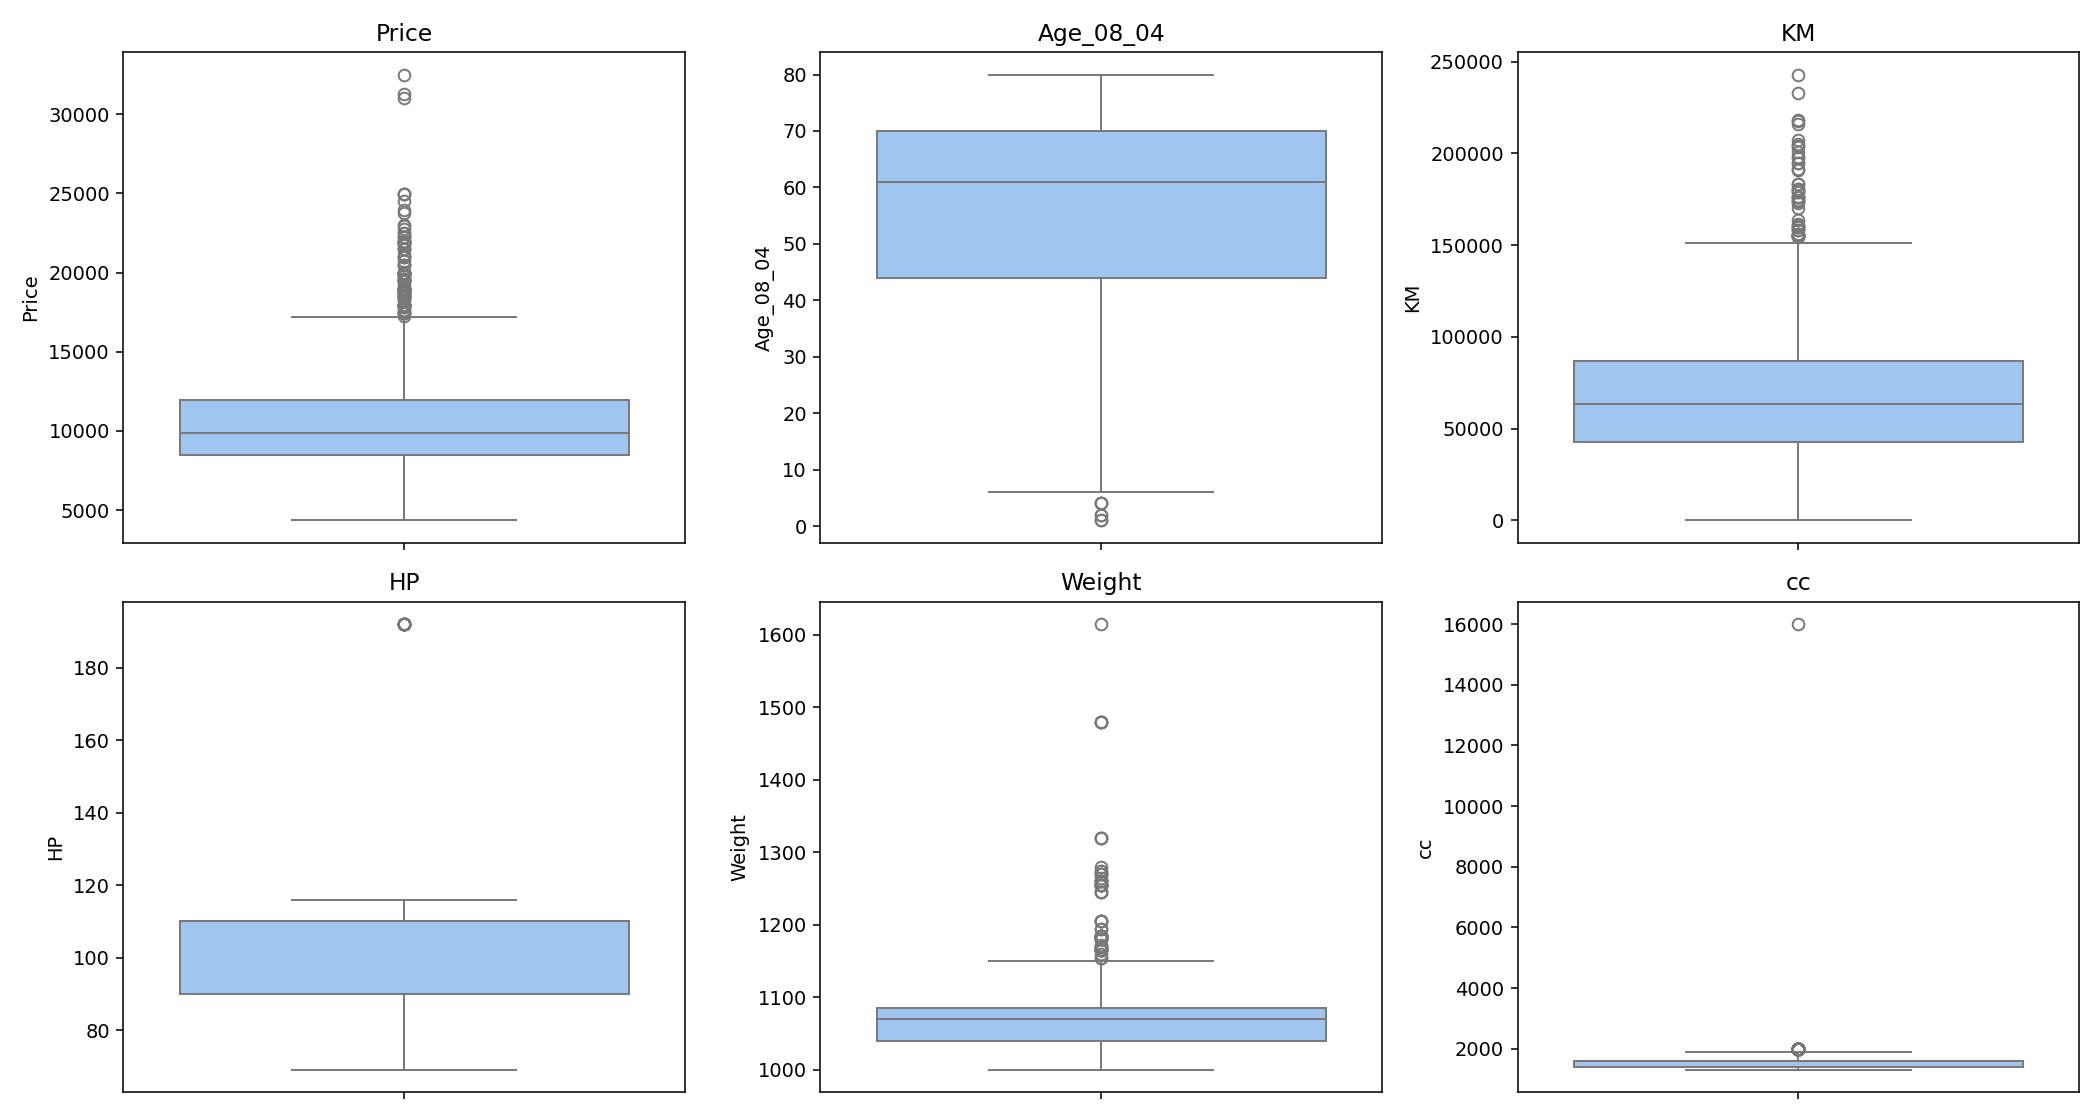

In [5]:
# Boxplots for key numeric variables (outlier check)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'Weight', 'cc']
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#93c5fd')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
# IQR-based outlier counts
for col in ['Price', 'KM', 'HP', 'Weight']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {n_out} outliers (IQR bounds: {lower:.0f} to {upper:.0f})')

Price: 110 outliers (IQR bounds: -1000 to 21400)
KM: 49 outliers (IQR bounds: -17325 to 143475)
HP: 11 outliers (IQR bounds: 74 to 122)
Weight: 66 outliers (IQR bounds: 962 to 1163)


**Assumption:** the flagged "outliers" (e.g. high-spec, low-mileage or high-HP cars) are treated as **genuine, valid observations** rather than data-entry errors — used-car prices naturally have a right-skewed tail from newer/premium trims. They are therefore **kept in the dataset** rather than removed, since dropping them would bias the model against legitimately expensive cars. This is revisited in Model 3 with a log transform of Price, which reduces the influence of this skew without discarding data.

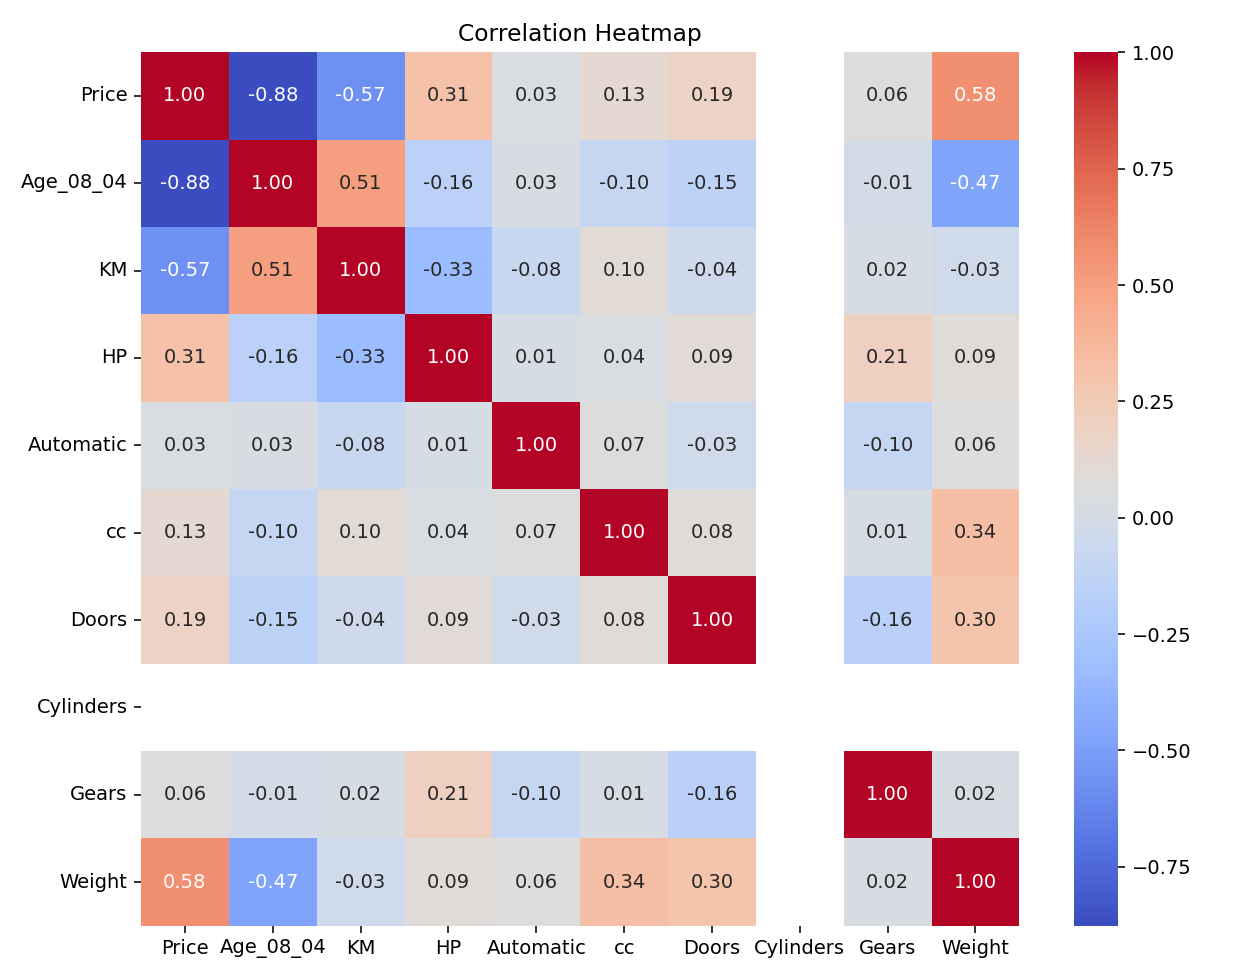

In [7]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

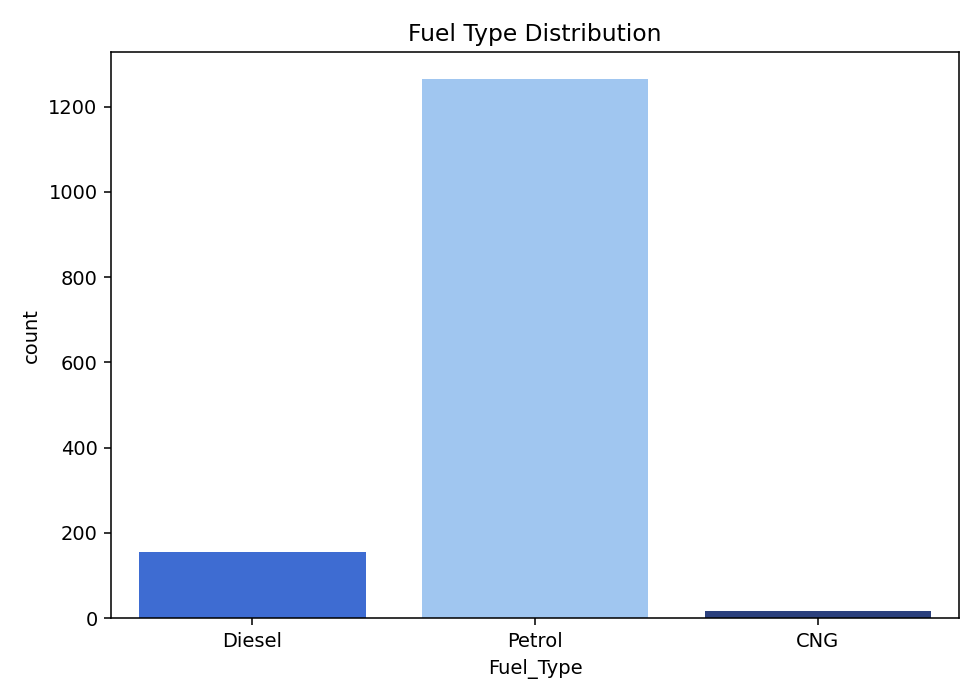

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64


In [8]:
# Fuel type distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='Fuel_Type', data=df, hue='Fuel_Type', palette=['#2563eb','#93c5fd','#1e3a8a'], legend=False)
plt.title('Fuel Type Distribution')
plt.tight_layout()
plt.show()
print(df['Fuel_Type'].value_counts())

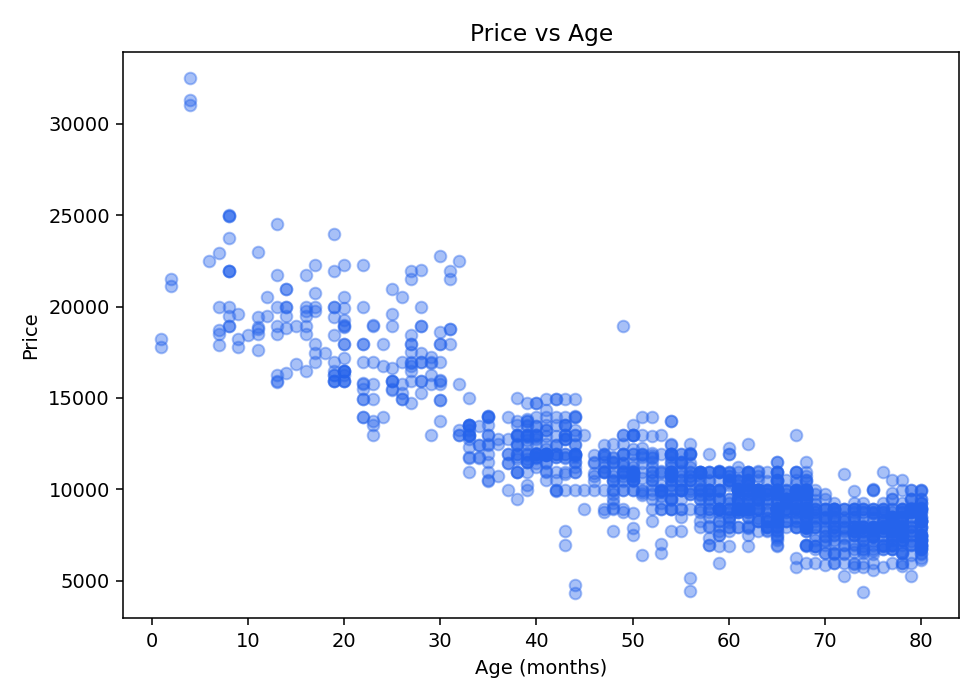

In [9]:
# Price vs Age — clearest single relationship in the data
plt.figure(figsize=(7, 5))
plt.scatter(df['Age_08_04'], df['Price'], alpha=0.4, color='#2563eb')
plt.xlabel('Age (months)'); plt.ylabel('Price (EUR)')
plt.title('Price vs Age')
plt.tight_layout()
plt.show()

**EDA insights:**
- `Age` has the strongest correlation with `Price` (r ≈ −0.88) — older cars are cheaper, as expected, and the relationship looks close to linear (slightly curved).
- `KM` is also negatively correlated with `Price` (r ≈ −0.57); `Weight` and `HP` are positively correlated.
- `Fuel_Type` is heavily imbalanced: 88% Petrol, 11% Diesel, 1% CNG — coefficients for CNG (the reference/dropped dummy level) should be interpreted cautiously given the tiny sample.
- `Cylinders` is constant across all rows (always 4) → **dropped**, it cannot explain any variance in Price.
- No missing values, so no imputation is required.

In [10]:
# Preprocessing: one-hot encode Fuel_Type, drop constant Cylinders column
df_enc = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)  # CNG is the reference level
df_enc = df_enc.rename(columns={'Age_08_04': 'Age'})
df_enc = df_enc.drop(columns=['Cylinders'])  # zero variance -> no predictive value

print('Final columns:', df_enc.columns.tolist())
df_enc.head()

Final columns: ['Price', 'Age', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


### 2. Train-Test Split (80/20)

In [11]:
target = 'Price'
features_all = [c for c in df_enc.columns if c != target]
X = df_enc[features_all]
y = df_enc[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

Training samples: 1148
Testing samples : 288


### 3. Multicollinearity Check (Variance Inflation Factor)
Before building the models, we check for multicollinearity among predictors using VIF (Variance Inflation Factor). A VIF above ~10 signals a feature is highly explainable by the other features.

In [12]:
def compute_vif(X):
    vif = {}
    for col in X.columns:
        other = [c for c in X.columns if c != col]
        lr = LinearRegression().fit(X[other], X[col])
        r2 = lr.score(X[other], X[col])
        vif[col] = 1/(1-r2) if r2 < 1 else np.inf
    return pd.Series(vif).sort_values(ascending=False)

print(compute_vif(X.astype(float)))

Fuel_Type_Diesel    11.317251
Fuel_Type_Petrol     9.702194
Weight               3.297145
HP                   2.299766
KM                   2.001790
Age                  1.920520
cc                   1.223892
Doors                1.217898
Gears                1.117413
Automatic            1.094550
dtype: float64


`Fuel_Type_Diesel` and `Fuel_Type_Petrol` show elevated VIF (>9). This is expected: the two dummy variables are mutually exclusive indicators drawn from the same 3-level categorical feature (Petrol/Diesel/CNG), so they are naturally correlated with each other by construction — not a sign of a genuine multicollinearity problem to fix. All other predictors have VIF well below 5, indicating no serious multicollinearity among the continuous/engineering features.

### 4. Model Building — Three Linear Regression Models

#### Model 1: Full Model (all 10 features)

In [13]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)
mae1 = mean_absolute_error(y_test, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
r2_1 = r2_score(y_test, pred1)

print(f'Train R2: {model1.score(X_train, y_train):.4f}')
print(f'Test  R2: {r2_1:.4f}')
print(f'MAE : {mae1:.2f}')
print(f'RMSE: {rmse1:.2f}')
print()
coef1 = pd.Series(model1.coef_, index=features_all).sort_values()
print('Coefficients:\n', coef1)
print('Intercept:', round(model1.intercept_, 2))

Train R2: 0.8703
Test  R2: 0.8349
MAE : 990.89
RMSE: 1484.27

Coefficients:
 Age                 -120.830458
Fuel_Type_Diesel     -68.548757
Doors                -60.310974
cc                    -0.030372
KM                    -0.016231
HP                    14.039479
Weight                25.884958
Automatic            148.830927
Gears                551.600710
Fuel_Type_Petrol    1370.808910
dtype: float64
Intercept: -14255.39


**Interpretation (Model 1):** holding everything else constant —
- Each additional **month of age** is associated with a price drop of ≈ €121.
- Each additional **1,000 km** on the odometer is associated with a drop of ≈ €16.
- Each additional **kg of weight** adds ≈ €26 to the price, and each extra **HP** adds ≈ €14.
- **Automatic** transmission adds ≈ €149 versus manual.
- Relative to a CNG car (the dropped reference category), a **Petrol** car is priced ≈ €1,371 higher and a **Diesel** car ≈ €69 lower — but with only 17 CNG cars in the data, this reference comparison is noisy and should be interpreted cautiously.
- `Doors` and `cc` have small, slightly counter-intuitive negative coefficients — likely a multicollinearity/confounding artifact rather than a genuine causal effect (e.g. cc is highly uniform, and Doors correlates with body style, which is itself correlated with other specs).

#### Model 2: Reduced Model (5 core numeric predictors)

In [14]:
features_m2 = ['Age', 'KM', 'HP', 'Weight', 'Automatic']
X2 = df_enc[features_m2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

pred2 = model2.predict(X2_test)
mae2 = mean_absolute_error(y2_test, pred2)
rmse2 = np.sqrt(mean_squared_error(y2_test, pred2))
r2_2 = r2_score(y2_test, pred2)

print(f'Train R2: {model2.score(X2_train, y2_train):.4f}')
print(f'Test  R2: {r2_2:.4f}')
print(f'MAE : {mae2:.2f}')
print(f'RMSE: {rmse2:.2f}')
print()
print(pd.Series(model2.coef_, index=features_m2))
print('Intercept:', round(model2.intercept_, 2))

Train R2: 0.8646
Test  R2: 0.8512
MAE : 1001.74
RMSE: 1409.10

Age         -120.759175
KM            -0.019890
HP            29.180675
Weight        19.553419
Automatic    296.433637
dtype: float64
Intercept: -5086.02


**Interpretation (Model 2):** using only the 5 strongest, least-collinear predictors gives a **slightly higher test R² (0.851 vs 0.835)** and **lower RMSE** than the full model, despite using half as many features — a sign that `Doors`, `cc`, and `Gears` in Model 1 were adding noise rather than genuine signal. This is a simpler, more parsimonious model with very similar coefficient values for the shared features (Age, KM), which is reassuring for stability.

#### Model 3: Log-Transformed Target (all features, log(Price))

In [15]:
# Price is right-skewed (see histogram) — modeling log(Price) can better satisfy the
# linear regression assumption of homoscedastic, normally-distributed residuals.
y_log = np.log(y)
X_train3, X_test3, y3_train, y3_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_train3, y3_train)

pred3_log = model3.predict(X_test3)
pred3 = np.exp(pred3_log)          # back-transform to EUR
y3_test_orig = np.exp(y3_test)

mae3 = mean_absolute_error(y3_test_orig, pred3)
rmse3 = np.sqrt(mean_squared_error(y3_test_orig, pred3))
r2_3 = r2_score(y3_test_orig, pred3)

print(f'Train R2 (log scale): {model3.score(X_train3, y3_train):.4f}')
print(f'Test  R2 (EUR scale, back-transformed): {r2_3:.4f}')
print(f'MAE  (EUR): {mae3:.2f}')
print(f'RMSE (EUR): {rmse3:.2f}')

Train R2 (log scale): 0.8502
Test  R2 (EUR scale, back-transformed): 0.8814
MAE  (EUR): 863.00
RMSE (EUR): 1257.70


**Interpretation (Model 3):** modeling `log(Price)` and converting predictions back to EUR gives the **best performance of the three models** (Test R² = 0.881, lowest MAE and RMSE), because it down-weights the influence of the small number of very expensive cars that were skewing the OLS fit in Models 1 and 2. In this specification, each coefficient represents an approximate **% change in price** per unit change in the predictor (e.g. the Age coefficient of ≈ −0.0104 means each extra month of age is associated with roughly a 1.0% drop in price, holding other features constant).

In [16]:
# Side-by-side comparison of the three models
comparison = pd.DataFrame({
    'Model': ['Model 1: Full (10 features)', 'Model 2: Reduced (5 features)', 'Model 3: Log-Price (10 features)'],
    'Test MAE': [mae1, mae2, mae3],
    'Test RMSE': [rmse1, rmse2, rmse3],
    'Test R2': [r2_1, r2_2, r2_3]
})
comparison

                               Model     Test MAE    Test RMSE   Test R2
0       Model 1: Full (10 features)   990.890000  1484.270000  0.834900
1     Model 2: Reduced (5 features)  1001.740000  1409.100000  0.851200
2  Model 3: Log-Price (10 features)   863.000000  1257.700000  0.881400

### 5. Regularization — Ridge and Lasso Regression

Ridge and Lasso are applied to the **full 10-feature set (Model 1's features)**, on **standardized** predictors (regularization penalizes coefficient magnitude, so features must be on the same scale for the penalty to be fair across features). The regularization strength (alpha) is chosen via 5-fold cross-validation.

In [17]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# OLS on scaled features, for a fair baseline comparison
ols_s = LinearRegression().fit(X_train_s, y_train)
pred_ols_s = ols_s.predict(X_test_s)

# Ridge with cross-validated alpha
ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5).fit(X_train_s, y_train)
pred_ridge = ridge_cv.predict(X_test_s)

# Lasso with cross-validated alpha
lasso_cv = LassoCV(alphas=np.logspace(-2, 3, 50), cv=5, max_iter=10000).fit(X_train_s, y_train)
pred_lasso = lasso_cv.predict(X_test_s)

print('Best Ridge alpha:', round(ridge_cv.alpha_, 2))
print('Best Lasso alpha:', round(lasso_cv.alpha_, 2))
print()
for name, pred in [('OLS (scaled)', pred_ols_s), ('Ridge', pred_ridge), ('Lasso', pred_lasso)]:
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f'{name:15s}: MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:.4f}')

Best Ridge alpha: 95.41
Best Lasso alpha: 47.15

OLS (scaled)   : MAE=  990.89  RMSE= 1484.27  R2=0.8349
Ridge          : MAE=  993.32  RMSE= 1453.63  R2=0.8416
Lasso          : MAE=  994.31  RMSE= 1450.66  R2=0.8423


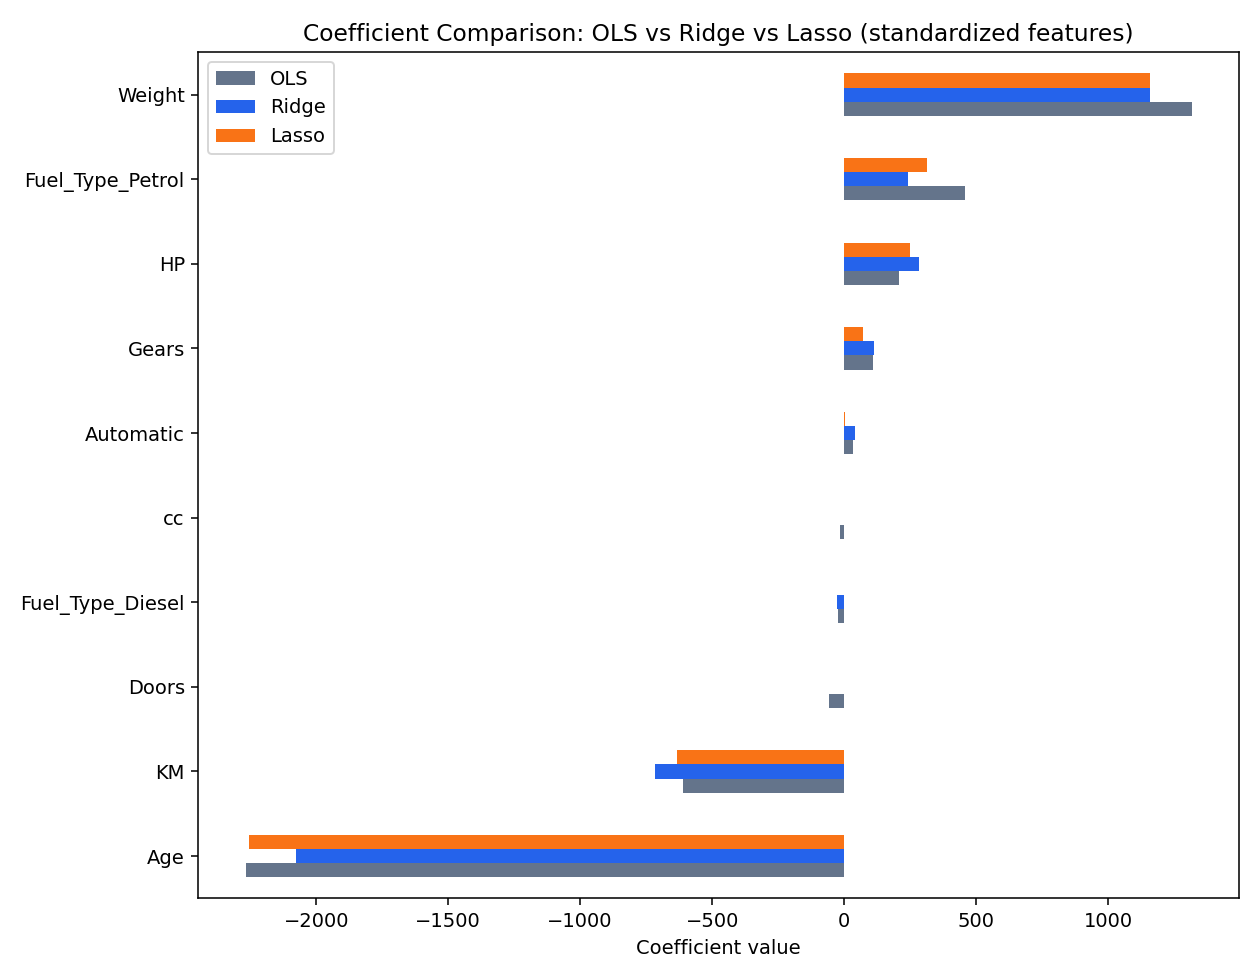

Features Lasso shrank to exactly 0: ['cc', 'Doors', 'Fuel_Type_Diesel']


In [18]:
coef_compare = pd.DataFrame({
    'OLS': ols_s.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
}, index=features_all).sort_values('OLS')

coef_compare.plot(kind='barh', figsize=(9, 7), color=['#64748b', '#2563eb', '#f97316'])
plt.title('Coefficient Comparison: OLS vs Ridge vs Lasso (standardized features)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('Features Lasso shrank to exactly 0:', 
      [f for f, c in zip(features_all, lasso_cv.coef_) if abs(c) < 1e-6])

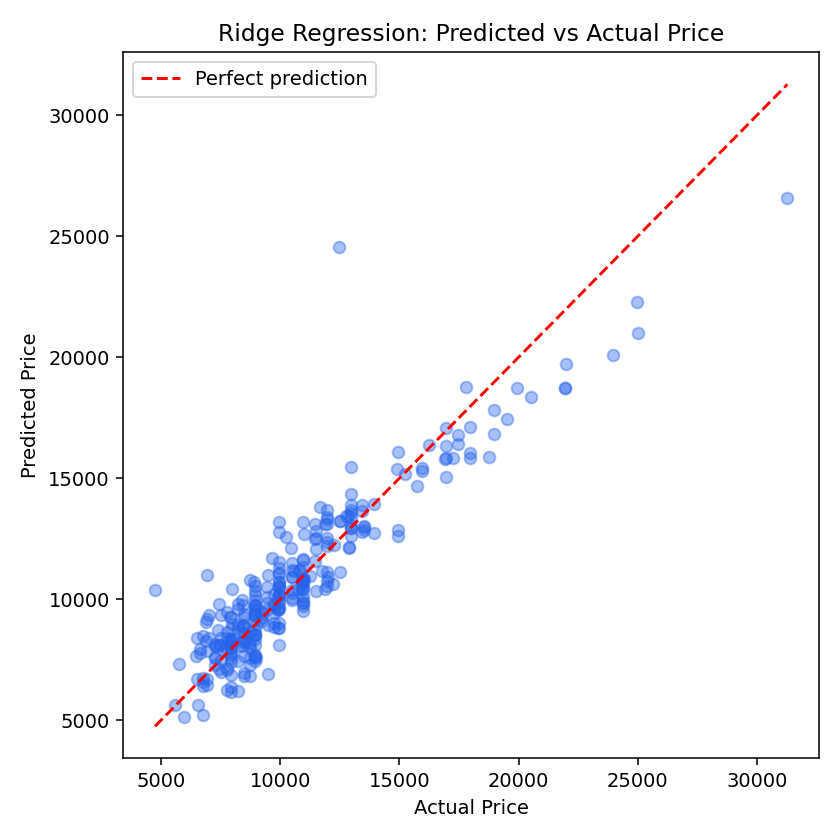

In [19]:
# Predicted vs Actual for the best-performing regularized model (Ridge)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_ridge, alpha=0.4, color='#2563eb')
lims = [min(y_test.min(), pred_ridge.min()), max(y_test.max(), pred_ridge.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Price'); plt.ylabel('Predicted Price')
plt.title('Ridge Regression: Predicted vs Actual Price')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation (Ridge & Lasso):**
- Both Ridge and Lasso slightly **outperform plain OLS on RMSE and R²** on the test set, confirming that some regularization helps generalization here (the improvement is modest because multicollinearity in this dataset, aside from the fuel-type dummies, is already low).
- **Ridge** shrinks all coefficients toward zero but keeps every feature in the model — useful when features are believed to genuinely all contribute a little.
- **Lasso** goes further and **zeroes out `cc`, `Doors`, and `Fuel_Type_Diesel` entirely**, effectively performing automatic feature selection. This matches the earlier observation from Model 2 that these features weren't adding much real signal to the full model.
- `Weight` and `Age` remain the two most influential features by far across all three approaches (OLS, Ridge, Lasso), reinforcing that they are the most robust, reliable price drivers in this dataset.

### Assumptions & Limitations
- **Linearity:** MLR assumes a linear relationship between predictors and price. Age vs Price is close to linear but shows a slight curve, partially addressed via the log-price model (Model 3).
- **No major multicollinearity:** confirmed via VIF, except for the two fuel-type dummies, which are correlated by construction (not a real modeling issue) rather than removed.
- **Outliers retained:** high-price/high-spec cars were kept as valid data rather than removed, on the assumption they reflect genuine premium trims rather than data errors; this trades some OLS fit for a model that still generalizes to higher-end cars.
- **Independence & homoscedasticity:** assumed but not formally tested here (e.g. no Durbin-Watson or Breusch-Pagan test was run) since dedicated diagnostic libraries were unavailable in this environment); the log-price model was used as a practical mitigation for the right-skew and potential heteroscedasticity visible in the Price histogram.
- **CNG under-representation:** only 17 of 1,436 cars are CNG-fueled, so any coefficient that compares Petrol/Diesel back to the CNG reference level should be treated as low-confidence.

---
## Interview Questions

**1. What is Normalization & Standardization, and how are they helpful?**

Both are feature-scaling techniques that put numeric variables on comparable scales:
- **Normalization** (min-max scaling) rescales each feature to a fixed range, typically [0, 1], via `(x - min) / (max - min)`. It's useful when features have known bounds and you want them to compete on equal footing (e.g. neural networks, image pixel values), but it's sensitive to outliers since a single extreme value stretches the whole scale.
- **Standardization** (Z-score scaling) rescales each feature to have mean 0 and standard deviation 1, via `(x - mean) / std`. It's less sensitive to outliers than min-max scaling and doesn't assume a bounded range, which makes it the more common default for regression-type models.

Both are helpful because:
- They put features with very different natural scales (e.g. `KM` in the tens of thousands vs `Automatic` as 0/1) on a comparable footing, so no single feature dominates purely due to its numeric magnitude.
- They're **required** for regularized models like Ridge and Lasso (used in Section 5 above) — since the penalty term shrinks coefficients based on their magnitude, an unscaled feature with large raw values would be penalized unfairly more or less than a small-scale feature representing an equally important effect.
- They help gradient-based optimization converge faster and more reliably in models like logistic regression, SVMs, and neural networks.
- Tree-based models (Decision Trees, Random Forests, Gradient Boosting) generally do **not** need feature scaling, since they split on threshold values rather than distances or magnitudes.

**2. What techniques can be used to address multicollinearity in multiple linear regression?**

- **Detect it first** — using correlation matrices and, more reliably, **Variance Inflation Factor (VIF)** (as done in Section 3 above); a VIF above ~5–10 is a common threshold for concern.
- **Drop or combine correlated features** — remove one of a pair of highly correlated predictors, or combine them into a single derived feature (e.g. a composite "engine size" index instead of separate `cc` and `HP`).
- **Regularization** — Ridge regression in particular directly counteracts multicollinearity by shrinking correlated coefficients, stabilizing the estimates even when predictors are correlated (as shown in Section 5, where Ridge's coefficients are smoother than OLS's). Lasso can additionally zero out redundant correlated features entirely.
- **Dimensionality reduction** — techniques like Principal Component Analysis (PCA) transform correlated features into a smaller set of uncorrelated components before modeling.
- **Collect more data** — multicollinearity is partly a symptom of limited variation in the sample; a larger, more varied dataset can sometimes reduce it, though this isn't always practical.
- **Center variables / avoid the dummy trap** — for categorical variables, always drop one dummy category (as done here with `drop_first=True` for `Fuel_Type`) to avoid perfect multicollinearity between all-category dummies.